In [64]:
import warnings
from __future__ import annotations
import datetime
from dataclasses import dataclass, field
from typing import Tuple, List, Optional
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import CountEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
)
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import xgboost as xgb
# from xgboost.callback import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

#### 1. Download data from Don’tGetKicked competition.

kaggle competitions download -c DontGetKicked<br>
or direct download

##### 1.1 Read all the data

In [65]:
path: str = "data/DontGetKicked/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(
    path.format(name="training"), parse_dates=["PurchDate"]
)
test_df: pd.DataFrame = pd.read_csv(
    path.format(name="test"), parse_dates=["PurchDate"]
)

##### 1.2 Drop columns with N/A > 50%

In [66]:
NA_threshold = 0.5
NA_percent = train_df.isnull().mean()
to_drop = NA_percent[NA_percent >= NA_threshold].index
train_df_wo_na = train_df.drop(columns=to_drop)

##### 1.3 Simple impute N/A for other columns and scale numeric

In [67]:
target = "IsBadBuy"
datetime_col = "PurchDate"
numeric = (
    train_df_wo_na.drop(target, axis=1)
    .select_dtypes(exclude=["object", "datetime"])
    .columns
)

categories = train_df_wo_na.select_dtypes(include="object").columns

numeric_pipeline = Pipeline(
    [
        ("num_imp", SimpleImputer(strategy="median")),
        ("st_scaler", StandardScaler()),
    ]
)

categories_pipeline = Pipeline(
    [
        ("cat_imp", SimpleImputer(strategy="constant", fill_value="unknown")),
    ]
)

col_tr = ColumnTransformer(
    transformers=[
        ("num_pipeline", numeric_pipeline, numeric),
        ("cat_pipeline", categories_pipeline, categories),
    ],
    remainder="drop",
)
train_df_tform_arr = col_tr.fit_transform(train_df_wo_na)

train_df_tform = pd.DataFrame(train_df_tform_arr)
train_df_tform.columns = numeric.to_list() + categories.to_list()
# add target and datetime col to final df
train_df_tform[datetime_col] = train_df_wo_na[datetime_col]
train_df_tform[target] = train_df_wo_na[target]

##### 1.4 Design the train/validation/test split. <br>Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. <br>Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [68]:
# all funcs from ML3
def split_by_date(
    X: pd.DataFrame,
    date_split: datetime.datetime,
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    info: pd.Series = X.dtypes
    date_in_df = [pd.api.types.is_datetime64_ns_dtype(x) for x in info.values]
    is_date_in_df = any(date_in_df)
    if not is_date_in_df:
        raise ValueError("No date col in df")

    # finds first entrance of datetype col
    date_col = info.index[date_in_df.index(True)]
    # sorts initial df to make proper split
    X = X.sort_values(by=date_col)
    X_train = X.loc[X[date_col] <= date_split]
    X_test = X.loc[X[date_col] > date_split]

    time_condition = X_train[date_col].max() < X_test[date_col].max()
    if not time_condition:
        raise ValueError("Split date cant provide proper split")

    return X_train, X_test


def validation_split_by_date(
    X: pd.DataFrame,
    validation_date: datetime.datetime,
    test_date: datetime.datetime,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    X_train, X_test = split_by_date(X, date_split=test_date)
    X_train, X_valid = split_by_date(X_train, date_split=validation_date)
    return X_train, X_valid, X_test


def check_split(df_list: List[pd.DataFrame], df_initial: pd.DataFrame) -> None:
    final_set: set = set(df_initial.index)
    for df in df_list:
        final_set -= set(df.index)
    print(final_set == set())
    [print(round(len(x) / len(df_initial), 2), end=" ") for x in df_list]

In [69]:
validation_date = datetime.datetime(year=2009, month=9, day=13)
test_date = datetime.datetime(year=2010, month=5, day=13)
X_train, X_valid, X_test = validation_split_by_date(
    X=train_df_tform, validation_date=validation_date, test_date=test_date
)
check_split(df_list=[X_train, X_valid, X_test], df_initial=train_df_tform)

True
0.33 0.34 0.33 

##### 1.5 Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables.<br> Be careful with data leakage (fit Encoder to training and apply to validation & test).<br> Consider another coding approach if you encounter new categorical values in validation & test (not seen in training): https://contrib.scikit-learn.org/category_encoders/count.html

In [70]:
cat_to_onehot_enc: list = []
cat_to_target_enc: list = []
for category in categories:
    # if there is many unique values we cant use OHE
    if X_train[category].value_counts().count() < 21:
        cat_to_onehot_enc.append(category)
    else:
        cat_to_target_enc.append(category)

In [71]:
# to avoid dummy variable trap use drop='first'
# when feature matrix becomes singular (determinant = 0)
one_hot_enc = OneHotEncoder(
    sparse_output=False,
    drop="first",
    feature_name_combiner="concat",
    handle_unknown="ignore",
)
cat_one_hot_enc = one_hot_enc.fit_transform(X_train[cat_to_onehot_enc])
cat_one_hot_enc = pd.DataFrame(
    cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
)

count_enc = CountEncoder(normalize=True, min_group_size=15)
cat_count_enc = count_enc.fit_transform(X_train[cat_to_target_enc])

X_train_ = pd.concat(
    [
        X_train[numeric].reset_index(drop=True),
        cat_one_hot_enc.reset_index(drop=True),
        cat_count_enc.reset_index(drop=True),
        X_train[target].reset_index(drop=True),
    ],
    axis=1,
)

In [72]:
df_transformed = [pd.DataFrame(), pd.DataFrame()]

for num, df in enumerate([X_valid, X_test]):
    cat_one_hot_enc = one_hot_enc.transform(df[cat_to_onehot_enc])
    cat_one_hot_enc = pd.DataFrame(
        cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
    )
    cat_count_enc = count_enc.transform(df[cat_to_target_enc])
    df_transformed[num] = pd.concat(
        [
            df[numeric].reset_index(drop=True),
            cat_one_hot_enc.reset_index(drop=True),
            cat_count_enc.reset_index(drop=True),
            df[target].reset_index(drop=True),
        ],
        axis=1,
    )

X_valid_, X_test_ = df_transformed

In [73]:
y_train_ = X_train_["IsBadBuy"]
X_train_ = X_train_.drop("IsBadBuy", axis=1).astype(np.float64)
y_valid_ = X_valid_["IsBadBuy"]
X_valid_ = X_valid_.drop("IsBadBuy", axis=1).astype(np.float64)
y_test_ = X_test_["IsBadBuy"]
X_test_ = X_test_.drop("IsBadBuy", axis=1).astype(np.float64)

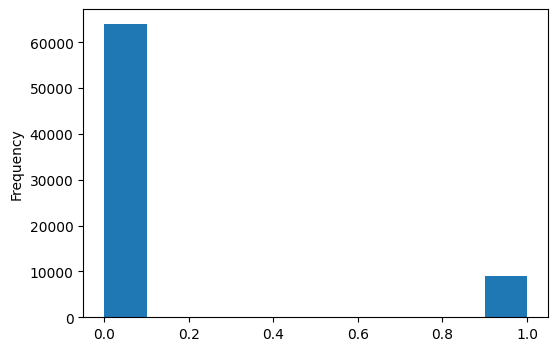

In [74]:
# change to pie
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
train_df["IsBadBuy"].plot.hist(ax=ax)
fig.show()

Target classes are imbalanced

In [75]:
def gini_score_sk(y_true, y_score):
    """using 2*ROC AUC - 1 approach"""
    return round(2 * roc_auc_score(y_true=y_true, y_score=y_score) - 1, 4)

#### 2. Create a Python class for Decision Tree Classifier and Decision Tree Regressor (MSE loss).
It should support fit, predict_proba, and predict methods. <br>
Also, the maximum depth (max_depth) must be a parameter of your class.<br> 
Use the Gini impurity criterion as a criterion for choosing the split.

- Create a separate class for Node. It should be able to hold data (sample features and targets),<br> compute Gini impurity, and have pointers to children (left and right nodes). <br>For the Regressor, use variance (MSE loss) instead of Gini impurity.
- Implement a function that finds the best possible split in the current node.
- Combine the previous steps into your working Decision Tree Classifier.
- Implement an Extra Randomized Tree by designing another function to find the best split.

In [76]:
@dataclass
class Node:
    feature: Optional[int] = None
    threshold: Optional[float] = None
    left: Optional['Node'] = None
    right: Optional['Node'] = None
    value: Optional[int] = None
    gain: Optional[float] = None
    class_distribution: Optional[np.ndarray] = None
    
    @staticmethod
    def gini_impurity(y, classes):
        if len(y) == 0:
            return 0.0
        counts = np.bincount(y, minlength=len(classes))
        probabilities = counts / len(y)
        return 1.0 - np.sum(probabilities ** 2)
    
    @staticmethod
    def var(y):
        if len(y) == 0:
            return 0.0
        return np.var(y)
    
    @staticmethod
    # to substitute implementing Extra Randomized Tree
    def entropy(y, classes):
        if len(y) == 0:
            return 0.0
        counts = np.bincount(y, minlength=len(classes))
        probabilities = counts / len(y)
        probabilities = probabilities[probabilities > 0]
        return -np.sum(probabilities * np.log2(probabilities))

In [77]:
@dataclass
class DecisionTreeClsf:
    max_depth: Optional[int] = None
    criterion: str = 'gini'
    random_state: int = 42
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    classes_: Optional[np.ndarray] = None
    root: Optional[Node] = None

    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)

    def calc_crit(self, y):
        if self.criterion == 'gini':
            return Node.gini_impurity(y, self.classes_)
        else:
            return Node.entropy(y, self.classes_)

    def calc_cls_distribution(self, y):
        counts = np.bincount(y, minlength=len(self.classes_))
        return counts / len(y)

    def best_split(self, X, y):
        n_samples, n_features = X.shape
        best_feature, best_threshold, best_gain = None, None, -1.0

        parent_crit = self.calc_crit(y)

        feature_indices = self.rng.permutation(n_features)
        
        for feature_idx in feature_indices:
            # Sorting by feature for efficient threshold search
            feature_values = X[:, feature_idx]
            sorted_indices = np.argsort(feature_values)
            sorted_features = feature_values[sorted_indices]
            sorted_y = y[sorted_indices]
            
            thresholds = np.unique(sorted_features)
            
            for threshold in thresholds:
                left_mask = sorted_features <= threshold
                right_mask = ~left_mask
                
                y_left = sorted_y[left_mask]
                y_right = sorted_y[right_mask]
                
                if len(y_left) >= self.min_samples_leaf and len(y_right) >= self.min_samples_leaf:
                    p = len(y_left) / len(y)
                    gain = parent_crit - p * self.calc_crit(y_left) - (1 - p) * self.calc_crit(y_right)
                    
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature_idx
                        best_threshold = threshold
        
        return best_feature, best_threshold, best_gain
    
    def build_tree(self, X, y, depth=0):
        n_samples = len(y)
        
        class_distribution = self.calc_cls_distribution(y)
        mode = np.argmax(class_distribution)
        
        if (self.max_depth is not None and depth >= self.max_depth) or \
            n_samples < self.min_samples_split or \
            len(np.unique(y)) == 1:
            return Node(value=mode, class_distribution=class_distribution)
        
        feature, threshold, gain = self.best_split(X, y)
        
        if feature is None or gain <= 0:
            return Node(value=mode, class_distribution=class_distribution)
        
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        X_left, y_left = X[left_mask], y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]
        
        left_node = self.build_tree(X_left, y_left, depth + 1)
        right_node = self.build_tree(X_right, y_right, depth + 1)
        
        return Node(
            feature=feature,
            threshold=threshold,
            left=left_node,
            right=right_node,
            gain=gain,
            class_distribution=class_distribution
        )

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        
        self.classes_ = np.unique(y)
        self.root = self.build_tree(X, y)

    def traverse_tree_proba(self, x, node):
        if node.value is not None:
            return node.class_distribution
        
        if x[node.feature] <= node.threshold:
            return self.traverse_tree_proba(x, node.left)
        else:
            return self.traverse_tree_proba(x, node.right)

    def predict_proba(self, X):
        X = np.asarray(X)
        proba = np.zeros((len(X), len(self.classes_)))
        
        for i, x in enumerate(X):
            proba[i] = self.traverse_tree_proba(x, self.root)
        
        return proba
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

In [78]:
@dataclass
class DecisionTreeRegressor(DecisionTreeClsf):
    max_depth: Optional[int] = None
    criterion: str = 'mse'
    random_state: int = 42
    min_samples_split: int = 2
    min_samples_leaf: int = 1
    root: Optional[Node] = None
    
    def __post_init__(self):
        self.rng = np.random.default_rng(self.random_state)
    
    def calc_crit(self, y):
        return Node.var(y)

    def calc_cls_distribution(self, y):
        return np.array([np.mean(y)])
    
    def build_tree(self, X, y, depth=0):
        n_samples = len(y)
        
        # For regression we use the mean value instead of the modal class
        mean_value = np.mean(y)
        class_distribution = self.calc_cls_distribution(y)
        
        if (self.max_depth is not None and depth >= self.max_depth) or \
            n_samples < self.min_samples_split or \
            len(np.unique(y)) == 1:
            return Node(value=mean_value, class_distribution=class_distribution)
        
        feature, threshold, gain = self.best_split(X, y)
        
        if feature is None or gain <= 0:
            return Node(value=mean_value, class_distribution=class_distribution)
        
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        X_left, y_left = X[left_mask], y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]
        
        left_node = self.build_tree(X_left, y_left, depth + 1)
        right_node = self.build_tree(X_right, y_right, depth + 1)
        
        return Node(
            feature=feature,
            threshold=threshold,
            left=left_node,
            right=right_node,
            gain=gain,
            class_distribution=class_distribution
        )
    
    def _predict_single(self, x):
        node = self.root
        while node.value is None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.class_distribution[0]
    
    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_single(x) for x in X])

#### 3. With your DecisionTree module, you must obtain a Gini score of at least 0.1 on the validation dataset.

#### 4.  Use sklearn's DecisionTreeClassifier and check its performance on the validation dataset. Is it better than your module? If so, why?

In [79]:
best_depth, best_gini = 1, 0

for depth in range(1, 10):
    model = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=depth)
    model.fit(X=X_train_, y=y_train_)
    y_pred = model.predict_proba(X=X_valid_)[:, 1]
    gini = gini_score_sk(y_true=y_valid_.values, y_score=y_pred)
    if best_gini < gini:
        best_gini = gini
        best_depth = depth
    print(f'{depth = } {gini = }')

depth = 1 gini = 0.2338
depth = 2 gini = 0.3266
depth = 3 gini = 0.4271
depth = 4 gini = 0.4366
depth = 5 gini = 0.443
depth = 6 gini = 0.4441
depth = 7 gini = 0.4166
depth = 8 gini = 0.3973
depth = 9 gini = 0.3932


At first gini improves then it can decrease due to overfitting

In [ ]:
out: pd.DataFrame = pd.DataFrame({"model": [], "Gini": []})

for model, name in [
    (DecisionTreeClsf(criterion='gini', random_state=42, max_depth=best_depth), 'My_DTC'),
    # insted of implementing Extra Randomized Tree use this: 
    (DecisionTreeClsf(criterion='entropy', random_state=42, max_depth=best_depth), 'My_Extra_Rnd_DTC'),
    (DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=best_depth), 'Sklearn_DTC'),
]:

    model.fit(X=X_train_, y=y_train_)
    y_pred = model.predict_proba(X=X_valid_)[:, 1]
    out.loc[len(out)] = {
        "model": name,
        "Gini": gini_score_sk(y_true=y_valid_.values, y_score=y_pred),
    }

out.reset_index(drop=True)

,model,Gini
0,My_DTC,0.4466
1,My_Extra_Rnd_DTC,0.4303
2,Sklearn_DTC,0.4441


Is it better than your module? If so, why?<br>No significant diff because our implementation is close to sklearn

#### 5. Implement the RandomForestClassifier and check its performance. <br>You have to improve the result of a single tree and get at least 0.15 Gini score on the validation dataset. Be able to set a fixed random seed.

In [81]:
@dataclass
class RandomForestClsf():
    pass

#### 6. Use your DecisionTree design class for GBDT classifier (Gradient Boosted Decision Trees Classifier).<br>This class must have max_depth, number_of_trees and max_features attributes.<br> You must compute the gradient of the binary cross-entropy loss function and implement incremental learning: train the next tree using the results of the previous trees.

In [82]:
@dataclass
class GBDT_Clsf():
    pass

#### 7. Use LightGBM, Catboost, and XGBoost for fitting on a training set and prediction on a validation set.<br> Review the documentation of the libraries and fine-tune the algorithms for the task.<br> Note key differences between each implementation.<br> Analyze special features of each algorithm (how does "categorical feature" work in Catboost, what is DART mode in XGBoost)?<br> Which GBDT model gives the best result? Can you explain why?

#### 8. Take the best model and estimate its performance on the test dataset:<br>check the Gini values on all three datasets for your best model: training Gini, valid Gini, test Gini.<br>Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitting or not? Explain.

Do you see a drop in performance when comparing the valid quality to the test quality? No, it's the other way around.
<br> Is your model overfitted or not? Explain. No, the model is not overfitted: all scores are in small range
<br>Big drop in perfomance = overfitting

#### 9*. Implement the ExtraTreesClassifier and check its performance. <br>You must improve the result of a single tree and obtain a Gini score of at least 0.12 on the validation dataset.

#### * Sources
- 1
- 2